# Week3 복습과제 - 변형 오토인코더(VAE) 코드 실습
- 작성자: 유다연
- 교재: 『딥러닝 파이토치 교과서』 13.2.2 변형 오토인코더 (p.695~708)
- 내용: 교재 코드 13-11 ~ 13-21 작성 및 실행 + 주석 + 개념 정리 + 손실 그래프(matplotlib) 추가
- 데이터셋: MNIST (28×28 손글씨 숫자)

## 0. 개념 정리

### 0-1. 오토인코더(AE) vs 변형 오토인코더(VAE)
- **AE**: 입력 → 인코더 → 압축(차원 축소) → 디코더 → 입력과 동일한 출력
  - 목적: 차원 축소 및 복원 → 생성 데이터의 확률 분포에는 관심 없음
- **VAE**: 입력 → 인코더 → **평균(μ)·표준편차(σ)** → 가우시안 분포에서 잠재 벡터 z 샘플링 → 디코더 → 출력
  - 목적: 데이터가 만들어지는 **확률 분포**를 학습 → 입력과 유사하지만 조금 다른 새로운 데이터 생성

### 0-2. 인코더 / 디코더
- 인코더 $q_\phi(z|x)$: x를 입력받아 잠재 벡터 z의 평균 $\mu_{z|x}$, 분산 $\Sigma_{z|x}$ 출력
- 디코더 $p_\theta(x|z)$: z를 입력받아 x의 평균·분산 출력 → 재구성 이미지 $x'$ 생성
- 변분추론(variational inference): 알기 어려운 이상적 분포 $p(z|x)$를 다루기 쉬운 가우시안 분포 $q_\phi(z|x)$로 근사

### 0-3. 목적 함수 (ELBO)
$$L(x^{(i)},\theta,\phi) = \underbrace{E_z[\log p_\theta(x^{(i)}|z)]}_{①\ 재구성} - \underbrace{D_{KL}(q_\phi(z|x^{(i)})\,\|\,p_\theta(z))}_{②\ 정규화}$$
- ① 재구성 항: 클수록 디코더가 원본을 잘 복원 → 코드에서는 **BCE(binary cross entropy)** 로 계산
- ② KL 발산 항: 작을수록 인코더 분포가 사전분포 $N(0, I)$에 가까움
- 위 값을 **최대화** = 손실 $L = -①+②$ 를 **최소화** → `loss = BCE + KLD`
- 가우시안끼리의 KL 발산 닫힌 형태: $D_{KL} = -\frac{1}{2}\sum(1+\log\sigma^2-\mu^2-\sigma^2)$

### 0-4. 재매개변수화 트릭 (Reparameterization Trick)
- 문제: z를 분포에서 "샘플링"하는 연산은 미분 불가 → 역전파 불가
- 해결: $z = \mu + \sigma \odot \epsilon,\ \ \epsilon \sim N(0, I)$
  - 무작위성은 ε로 분리 → μ, σ에 대해서는 미분 가능
- 인코더는 σ 대신 **log σ²(log_var)** 출력 → 값의 범위 제약(양수 조건) 없이 학습 가능, $\sigma = \exp(0.5 \cdot \log\sigma^2)$ 로 복원

## 1. 환경 준비
- 텐서보드 사용을 위한 `tensorboardX` 설치 필요 (최초 1회)

In [1]:
# !pip install tensorboardX

## 2. 코드 13-11 필요한 라이브러리 호출

In [2]:
import datetime
import os
from tensorboardX import SummaryWriter   # 텐서보드에 학습 로그(손실 등)를 기록하기 위한 도구

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

# GPU 사용 가능 시 cuda, 아니면 cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## 3. 코드 13-12 데이터셋을 내려받은 후 텐서 변환
- `ToTensor()`: 이미지를 [0, 1] 범위 텐서로 변환 → 디코더 출력(sigmoid, 0~1) 및 BCE 손실과 범위 일치

In [3]:
transform = transforms.Compose([transforms.ToTensor()])   # PIL 이미지 → 텐서 (0~1 정규화)

train_dataset = datasets.MNIST(
    root="../chap13/data", train=True, transform=transform, download=True)   # 훈련 데이터 60,000장

test_dataset = datasets.MNIST(
    root="../chap13/data", train=False, transform=transform, download=True)  # 테스트 데이터 10,000장

train_loader = DataLoader(
    train_dataset, batch_size=100, shuffle=True, num_workers=4, pin_memory=False)   # 훈련 데이터는 섞어서 사용

test_loader = DataLoader(
    test_dataset, batch_size=100, shuffle=False, num_workers=4)

print(len(train_dataset), len(test_dataset))

60000 10000


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:431: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## 4. 코드 13-13 인코더 네트워크 생성
- 입력 x(784) → 은닉층 2개(400) → 평균(mean)과 로그 분산(log_var) 각각 출력(200)

In [4]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.input1 = nn.Linear(input_dim, hidden_dim)    # 784 → 400
        self.input2 = nn.Linear(hidden_dim, hidden_dim)   # 400 → 400
        self.mean = nn.Linear(hidden_dim, latent_dim)     # 400 → 200 : 잠재 벡터의 평균 μ
        self.var = nn.Linear(hidden_dim, latent_dim)      # 400 → 200 : 잠재 벡터의 로그 분산 log σ²

        self.LeakyReLU = nn.LeakyReLU(0.2)   # 음수 구간 기울기 0.2 → 뉴런이 죽는 문제 완화
        self.training = True

    def forward(self, x):
        h_ = self.LeakyReLU(self.input1(x))
        h_ = self.LeakyReLU(self.input2(h_))
        mean = self.mean(h_)
        log_var = self.var(h_)   # 분산 대신 log 분산 출력 → 음수 값도 허용되어 학습 안정
        return mean, log_var     # 인코더 네트워크에서 평균과 분산을 반환

## 5. 코드 13-14 디코더 네트워크
- 잠재 벡터 z(200) → 은닉층 2개(400) → 출력(784)
- 마지막에 sigmoid → 픽셀 값 0~1 범위로 재구성

In [5]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.hidden1 = nn.Linear(latent_dim, hidden_dim)   # 200 → 400
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)   # 400 → 400
        self.output = nn.Linear(hidden_dim, output_dim)    # 400 → 784
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.LeakyReLU(self.hidden1(x))
        h = self.LeakyReLU(self.hidden2(h))
        x_hat = torch.sigmoid(self.output(h))
        return x_hat   # 디코더 결과는 시그모이드를 통과했으므로 0~1 값을 가짐

## 6. 코드 13-15 변형 오토인코더 네트워크
- 인코더 → 재매개변수화(z = μ + σ·ε) → 디코더

In [6]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    # ① 재매개변수화: z 벡터 샘플링 용도
    #    (인자 이름은 var이지만 실제로는 표준편차 σ가 전달됨)
    def reparameterization(self, mean, var):
        epsilon = torch.randn_like(var).to(device)   # ε ~ N(0, I) : 무작위성을 ε로 분리
        z = mean + var * epsilon                     # z = μ + σ·ε → μ, σ에 대해 미분 가능
        return z

    def forward(self, x):
        mean, log_var = self.Encoder(x)   # ② 인코더에서 평균과 log σ² 받아옴
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))   # σ = exp(0.5·log σ²)
        x_hat = self.Decoder(z)
        return x_hat, mean, log_var   # 디코더 결과와 평균, 표준편차(log를 취한 표준편차)를 반환

## 7. 코드 13-16 인코더와 디코더 객체 초기화

In [7]:
x_dim = 784        # 입력 차원 (28×28)
hidden_dim = 400   # 은닉층 차원
latent_dim = 200   # 잠재 벡터 z 차원
epochs = 30
batch_size = 100

encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)
print(model)

Model(
  (Encoder): Encoder(
    (input1): Linear(in_features=784, out_features=400, bias=True)
    (input2): Linear(in_features=400, out_features=400, bias=True)
    (mean): Linear(in_features=400, out_features=200, bias=True)
    (var): Linear(in_features=400, out_features=200, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
  (Decoder): Decoder(
    (hidden1): Linear(in_features=200, out_features=400, bias=True)
    (hidden2): Linear(in_features=400, out_features=400, bias=True)
    (output): Linear(in_features=400, out_features=784, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
)


## 8. 코드 13-17 손실 함수 정의
- 손실 $L = -E_{z\sim q(z|x)}[\log p_\theta(x|z)] + D_{KL}(q(z|x)\|p_\theta(z))$
  - ⓐ 재구성 오차: `binary_cross_entropy(x_hat, x, reduction='sum')`
  - ⓑ KL 발산: `-0.5 * sum(1 + log_var - mean² - exp(log_var))`
- 최종 손실 = 두 값의 합

In [8]:
def loss_function(x, x_hat, mean, log_var):
    # ⓐ 재구성 오차: 원본 x와 재구성 x_hat의 BCE (배치 전체 합)
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction='sum')
    # ⓑ KL 발산: q(z|x)=N(μ, σ²)와 사전분포 N(0, I) 사이의 거리 (닫힌 형태)
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss, KLD

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 9. 코드 13-18 모델 학습 함수 정의
- `SummaryWriter(saved_loc)`: 로그 저장 경로 지정 (기본값 `./runs`)
- `add_scalar(태그, y값, x값)`: 텐서보드 그래프에 값 기록

In [9]:
saved_loc = 'scalar/'              # 텐서보드에서 사용할 경로
writer = SummaryWriter(saved_loc)

model.train()
def train(epoch, model, train_loader, optimizer):
    train_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):   # 레이블은 사용하지 않음 (비지도 학습)
        x = x.view(batch_size, x_dim)   # (100, 1, 28, 28) → (100, 784) 평탄화
        x = x.to(device)

        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        BCE, KLD = loss_function(x, x_hat, mean, log_var)
        loss = BCE + KLD
        # x축 = 전체 누적 스텝 (batch_idx + epoch × 에포크당 배치 수 600)
        writer.add_scalar("Train/Reconstruction Error", BCE.item(), batch_idx + epoch *
                          (len(train_loader.dataset)/batch_size))
        writer.add_scalar("Train/KL-Divergence", KLD.item(), batch_idx + epoch *
                          (len(train_loader.dataset)/batch_size))
        writer.add_scalar("Train/Total Loss", loss.item(), batch_idx + epoch *
                          (len(train_loader.dataset)/batch_size))

        train_loss += loss.item()
        loss.backward()    # 역전파: 손실(= -ELBO)을 줄이는 방향 = 가능도를 높이는 방향으로 θ, φ 업데이트
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\t Loss: {:.6f}'.format(
                epoch, batch_idx * len(x), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(x)))   # 샘플 1개당 손실

    print("======> Epoch: {} Average loss: {:.4f}".format(
        epoch, train_loss / len(train_loader.dataset)))

## 10. 코드 13-19 모델 평가 함수 정의
- `torch.no_grad()`: 평가 시 기울기 계산 생략
- 첫 배치에서 원본 8장 + 재구성 8장을 이어 붙여 텐서보드 이미지로 저장

In [10]:
def test(epoch, model, test_loader):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(test_loader):
            x = x.view(batch_size, x_dim)
            x = x.to(device)
            x_hat, mean, log_var = model(x)
            BCE, KLD = loss_function(x, x_hat, mean, log_var)
            loss = BCE + KLD

            writer.add_scalar("Test/Reconstruction Error", BCE.item(), batch_idx +
                              epoch * (len(test_loader.dataset)/batch_size))   # 테스트 데이터셋에 대해서도 오차를 로그에 저장
            writer.add_scalar("Test/KL-Divergence", KLD.item(), batch_idx + epoch *
                              (len(test_loader.dataset)/batch_size))
            writer.add_scalar("Test/Total Loss", loss.item(), batch_idx + epoch *
                              (len(test_loader.dataset)/batch_size))
            test_loss += loss.item()

            if batch_idx == 0:
                n = min(x.size(0), 8)
                comparison = torch.cat([x[:n], x_hat.view(batch_size, x_dim)[:n]])   # 위: 원본, 아래: 재구성
                grid = torchvision.utils.make_grid(comparison.cpu())
                writer.add_image("Test image - Above: Real data, below: reconstruction "
                                 "data", grid, epoch)

## 11. 코드 13-20 모델 학습
- 학습 종료 후 `writer.close()` 필수 → 호출하지 않으면 loss 값 미저장

In [11]:
from tqdm.auto import tqdm
for epoch in tqdm(range(0, epochs)):
    train(epoch, model, train_loader, optimizer)
    test(epoch, model, test_loader)
    print("\n")
writer.close()   # ① 학습 종료 후 writer를 닫아 로그 저장

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:437: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Train Epoch: 0 [0/60000 (0%)]	 Loss: 544.255508


Train Epoch: 0 [10000/60000 (17%)]	 Loss: 201.157832


Train Epoch: 0 [20000/60000 (33%)]	 Loss: 180.807246


Train Epoch: 0 [30000/60000 (50%)]	 Loss: 167.893066


...

Train Epoch: 29 [20000/60000 (33%)]	 Loss: 98.180059


Train Epoch: 29 [30000/60000 (50%)]	 Loss: 96.807461


Train Epoch: 29 [40000/60000 (67%)]	 Loss: 99.783086


Train Epoch: 29 [50000/60000 (83%)]	 Loss: 101.318398


======> Epoch: 29 Average loss: 100.2340


## 12. 코드 13-21 텐서보드에서 오차 확인
- `%load_ext tensorboard`: 주피터에서 텐서보드 매직 커맨드 사용
- `--logdir`: 로그 저장 위치 / `--port`: 브라우저 접속 포트 (기본 6006, 예제는 6013)
- ※ 텐서보드 화면은 노트북 파일에 저장되지 않음 → 아래 13번에서 같은 로그를 matplotlib으로 시각화

In [12]:
%load_ext tensorboard
%tensorboard --logdir scalar --port=6013

## 13. [추가] 손실 그래프 시각화 (matplotlib)
- 텐서보드에 기록된 이벤트 파일(`scalar/`)을 직접 읽어 교재 그림 13-14 ~ 13-19와 같은 그래프 재현
- 연한 선: 배치별 값 / 진한 선: 이동평균

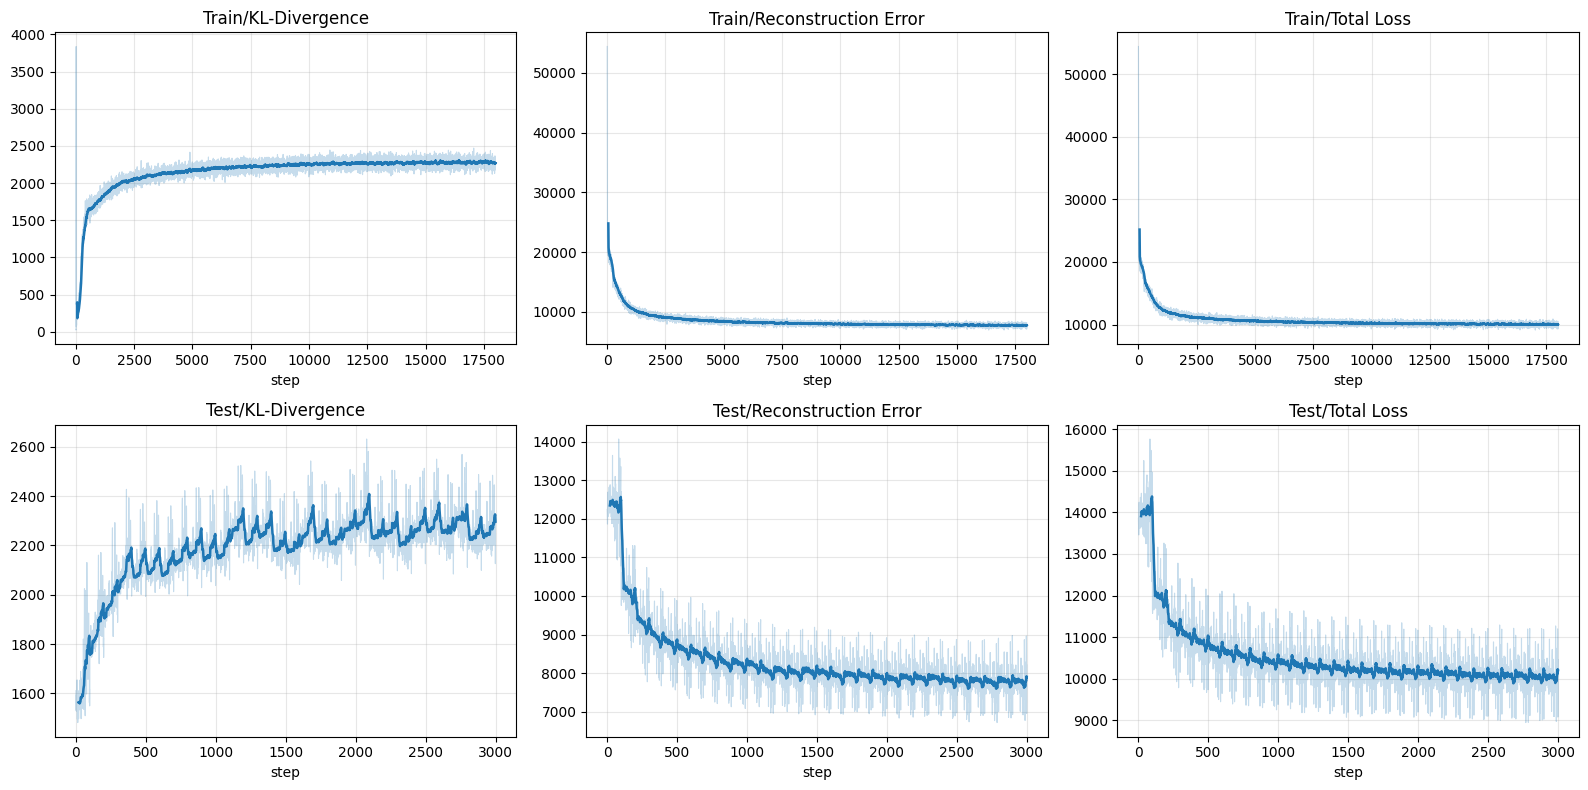

In [13]:
import numpy as np
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

ea = EventAccumulator(saved_loc, size_guidance={'scalars': 0})   # 0 = 모든 값 로드 (기본값은 일부만 샘플링)
ea.Reload()

def load(tag):
    ev = ea.Scalars(tag.replace(' ', '_'))   # tensorboardX가 태그의 공백을 '_'로 저장
    steps = np.array([e.step for e in ev])
    vals = np.array([e.value for e in ev])
    order = np.argsort(steps)
    return steps[order], vals[order]

def smooth(v, k=50):   # 이동평균으로 추세 확인
    return np.convolve(v, np.ones(k) / k, mode='valid')

tags = ["KL-Divergence", "Reconstruction Error", "Total Loss"]
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for r, split in enumerate(["Train", "Test"]):
    k = 50 if split == "Train" else 20
    for c, t in enumerate(tags):
        s, v = load(f"{split}/{t}")
        ax = axes[r, c]
        ax.plot(s, v, alpha=0.25, color="tab:blue", linewidth=0.8)
        ax.plot(s[k - 1:], smooth(v, k), color="tab:blue", linewidth=1.8)
        ax.set_title(f"{split}/{t}")
        ax.set_xlabel("step")
        ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

- 에포크 단위 평균 손실 (샘플 1개당)

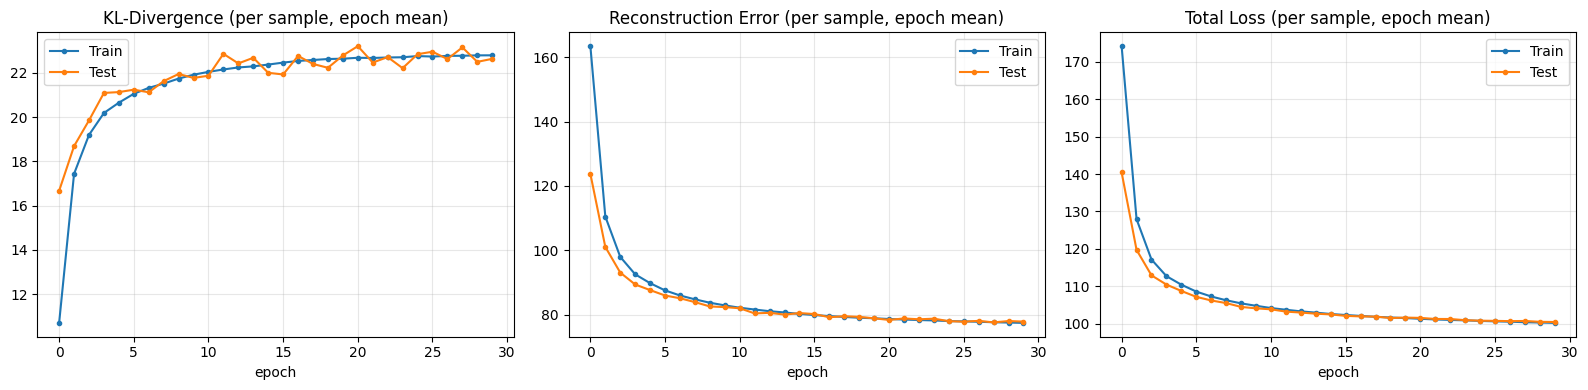

Train KL-Divergence          epoch0:    10.70  →  epoch29:    22.79
Train Reconstruction Error   epoch0:   163.46  →  epoch29:    77.44
Train Total Loss             epoch0:   174.16  →  epoch29:   100.23
Test  KL-Divergence          epoch0:    16.67  →  epoch29:    22.63
Test  Reconstruction Error   epoch0:   123.76  →  epoch29:    77.84
Test  Total Loss             epoch0:   140.43  →  epoch29:   100.47


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for c, t in enumerate(tags):
    for split, n_batch in [("Train", 600), ("Test", 100)]:
        s, v = load(f"{split}/{t}")
        ep_mean = v.reshape(epochs, n_batch).mean(axis=1) / batch_size   # 에포크별 평균 → 샘플당 값
        axes[c].plot(range(epochs), ep_mean, marker="o", markersize=3, label=split)
    axes[c].set_title(f"{t} (per sample, epoch mean)")
    axes[c].set_xlabel("epoch")
    axes[c].legend()
    axes[c].grid(alpha=0.3)
plt.tight_layout()
plt.show()

for split, n_batch in [("Train", 600), ("Test", 100)]:
    for t in tags:
        s, v = load(f"{split}/{t}")
        ep_mean = v.reshape(epochs, n_batch).mean(axis=1) / batch_size
        print(f"{split:5s} {t:22s} epoch0: {ep_mean[0]:8.2f}  →  epoch{epochs-1}: {ep_mean[-1]:8.2f}")

## 14. 결과 정리
- 학습 결과: 30 에포크 후 훈련 평균 손실 **174.16 → 100.23** (교재 결과 173.28 → 100.06과 거의 동일)
- 테스트 평균 손실(샘플당): 140.43 → 100.47 → 훈련·테스트 손실 차이가 작아 과적합 없음
- 재구성 오차(BCE): 163.46 → 77.44 (훈련) / 123.76 → 77.84 (테스트) → 원본 이미지 복원 능력 향상
- KL 발산: 10.70 → 22.79 (훈련) / 16.67 → 22.63 (테스트) → 초반 증가 후 일정 범위에서 수렴
- 해석
  - 재구성 오차와 KL 발산은 **반비례(trade-off)** 관계
    - 학습 초반: 인코더 출력이 N(0, I)에 가까워 KLD는 작지만 복원 성능 낮음
    - 학습 진행: 복원을 위해 잠재 공간에 정보를 담기 시작 → KLD 증가, 재구성 오차 감소
  - KLD가 계속 증가하지 않고 수렴 → $q_\phi(z|x^{(i)})$가 사전분포 $p_\theta(z)$와 적당히 가까운 상태 유지
  - 전체 손실(= -ELBO)은 꾸준히 감소 → 모델 가능도 증가
- 실습 중 확인 사항
  - `SummaryWriter`는 태그의 공백을 `_`로 바꿔 저장 (예: `Train/Total Loss` → `Train/Total_Loss`)
  - 테스트 그래프의 톱니 모양: 테스트 로더가 `shuffle=False`라 매 에포크 같은 순서의 배치를 보기 때문에 배치별 난이도 패턴이 반복되어 나타남
